In [ ]:
import pandas as pd
import numpy as np

dataset = pd.read_csv('/content/drive/MyDrive/dataset/Nutrition__Physical_Activity__and_Obesity_-_Behavioral_Risk_Factor_Surveillance_System.csv')

df = pd.DataFrame(dataset)
df.head()

/tmp/ipython-input-1497252999.py:4: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  dataset = pd.read_csv('/content/drive/MyDrive/dataset/Nutrition__Physical_Activity__and_Obesity_-_Behavioral_Risk_Factor_Surveillance_System.csv')


,YearStart,YearEnd,LocationAbbr,LocationDesc,Datasource,Class,Topic,Question,Data_Value_Unit,Data_Value_Type,...,GeoLocation,ClassID,TopicID,QuestionID,DataValueTypeID,LocationID,StratificationCategory1,Stratification1,StratificationCategoryId1,StratificationID1
0,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$15,000 - $24,999",INC,INC1525
1,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$25,000 - $34,999",INC,INC2535
2,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$35,000 - $49,999",INC,INC3550
3,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$50,000 - $74,999",INC,INC5075
4,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$75,000 or greater",INC,INC75PLUS


In [ ]:
df.shape

(110880, 33)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110880 entries, 0 to 110879
Data columns (total 33 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   YearStart                   110880 non-null  int64  
 1   YearEnd                     110880 non-null  int64  
 2   LocationAbbr                110880 non-null  object 
 3   LocationDesc                110880 non-null  object 
 4   Datasource                  110880 non-null  object 
 5   Class                       110880 non-null  object 
 6   Topic                       110880 non-null  object 
 7   Question                    110880 non-null  object 
 8   Data_Value_Unit             4620 non-null    object 
 9   Data_Value_Type             110880 non-null  object 
 10  Data_Value                  97666 non-null   float64
 11  Data_Value_Alt              97666 non-null   float64
 12  Data_Value_Footnote_Symbol  13214 non-null   object 
 13  Data_Value_Foo

(a) When and by whom the dataset was created

The dataset is created and maintained by the Centers for Disease Control and Prevention (CDC), United States.
The Behavioral Risk Factor Surveillance System (BRFSS) survey started in 1984 as a collaborative project between CDC and U.S. states/territories.
This particular compiled dataset (Nutrition, Physical Activity, and Obesity subset) is regularly updated every year. The version I used includes data from 2011 to recent years (up to 2021–2023 in many records), published openly on data.cdc.gov.

(b) How and from where the dataset was accessed

The dataset was downloaded as a CSV file from the official open data portal of the CDC:
Link: https://data.cdc.gov/Nutrition-Physical-Activity-and-Obesity/Nutrition-Physical-Activity-and-Obesity-Behavioral-Risk/vhfl-3wku
Direct download:
https://data.cdc.gov/api/views/vhfl-3wku/rows.csv?accessType=DOWNLOAD
I saved it in my Google Drive and loaded it using pd.read_csv().

c) Justification of alignment with the selected UNSDG

This dataset aligns very well with United Nations Sustainable Development Goal 3: Good Health and Well-being, specifically targets:

3.4 — Reduce premature mortality from non-communicable diseases (NCDs) through prevention and treatment, and promote mental health and well-being.
3.d — Strengthen the capacity for early warning, risk reduction, and management of national and global health risks.

Obesity, poor nutrition, and physical inactivity are major risk factors for NCDs like diabetes, heart disease, and some cancers. This dataset provides state-level prevalence estimates of obesity, physical activity, fruit/vegetable consumption, and related behaviors — helping governments and health organizations monitor progress, plan interventions, and reduce health burdens.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Step 1: Remove any extra whitespace in column names
df.columns = df.columns.str.strip()

# Step 2: Basic info
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nUnique values in important columns:")
print("YearStart:", df['YearStart'].unique())
print("Class:", df['Class'].unique())
print("Topic:", df['Topic'].unique())
print("Question (top 10 most frequent):")
print(df['Question'].value_counts().head(10))

# Step 3: Focus only on rows with actual numeric values
df_valid = df[df['Data_Value'].notna()].copy()

print("\nRows with valid Data_Value:", df_valid.shape[0])

# Step 4: Choose obesity question
obesity_q = "Percent of adults aged 18 years and older who have obesity"
df_obesity = df_valid[df_valid['Question'] == obesity_q].copy()

print("\nRows for obesity question:", df_obesity.shape[0])

# Step 5: Create binary target for classification example
df_obesity['High_Obesity'] = (df_obesity['Data_Value'] >= 30).astype(int)

# Step 6: Summary statistics of numeric columns
print("\nSummary statistics (obesity subset):")
numeric_cols = ['Data_Value', 'Low_Confidence_Limit', 'High_Confidence_Limit', 'Sample_Size']
print(df_obesity[numeric_cols].describe())

# Step 7: Value counts of stratification variables
print("\nStratification by Income (top):")
print(df_obesity['Income'].value_counts(dropna=False))
print("\nStratification by Education:")
print(df_obesity['Education'].value_counts(dropna=False))
print("\nStratification by Sex:")
print(df_obesity['Sex'].value_counts(dropna=False))

Shape: (110880, 33)

Missing values:
 YearStart                          0
YearEnd                            0
LocationAbbr                       0
LocationDesc                       0
Datasource                         0
Class                              0
Topic                              0
Question                           0
Data_Value_Unit               106260
Data_Value_Type                    0
Data_Value                     13214
Data_Value_Alt                 13214
Data_Value_Footnote_Symbol     97666
Data_Value_Footnote            97666
Low_Confidence_Limit           13214
High_Confidence_Limit          13214
Sample_Size                    13214
Total                         106920
Age(years)                     87120
Education                      95040
Sex                           102960
Income                         83160
Race/Ethnicity                 79200
GeoLocation                     2016
ClassID                            0
TopicID                            0


/tmp/ipython-input-2130733805.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(data=df_obesity, x='YearStart', y='Data_Value', estimator='mean', ci=95)


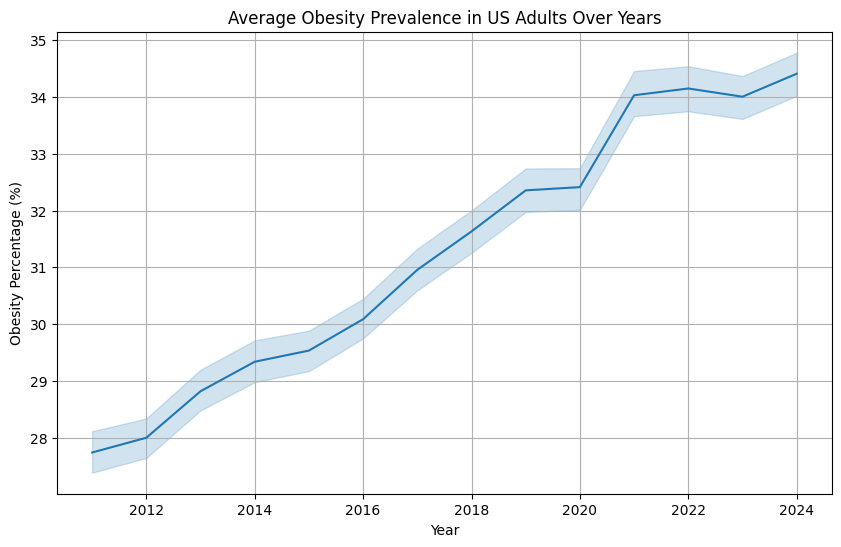

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_obesity, x='YearStart', y='Data_Value', estimator='mean', ci=95)
plt.title('Average Obesity Prevalence in US Adults Over Years')
plt.xlabel('Year')
plt.ylabel('Obesity Percentage (%)')
plt.grid(True)
plt.show()

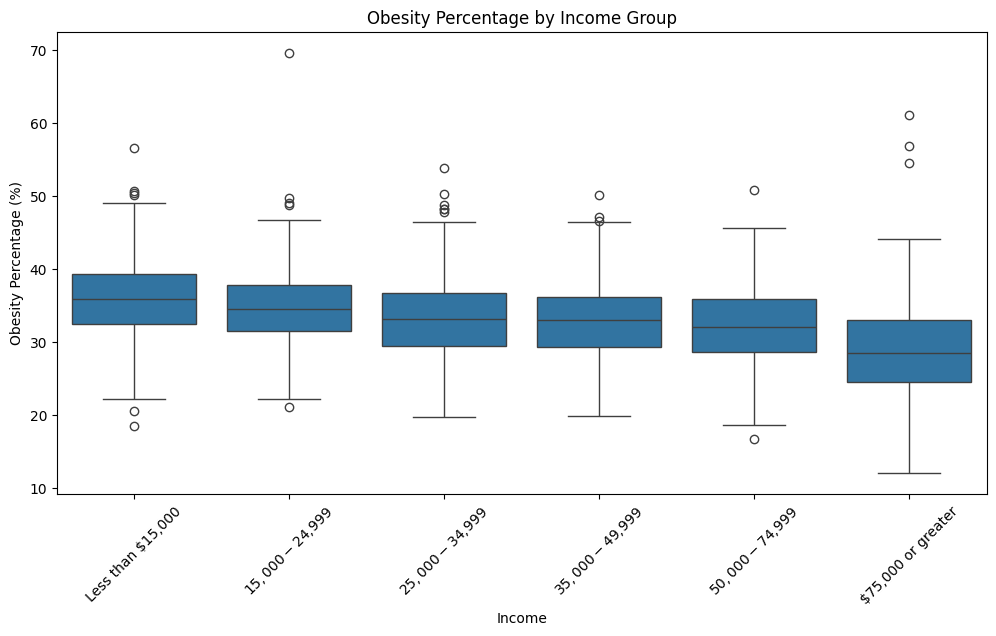

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_obesity, x='Income', y='Data_Value', order=[
    'Less than $15,000', '$15,000 - $24,999', '$25,000 - $34,999',
    '$35,000 - $49,999', '$50,000 - $74,999', '$75,000 or greater'
])
plt.title('Obesity Percentage by Income Group')
plt.xticks(rotation=45)
plt.ylabel('Obesity Percentage (%)')
plt.show()

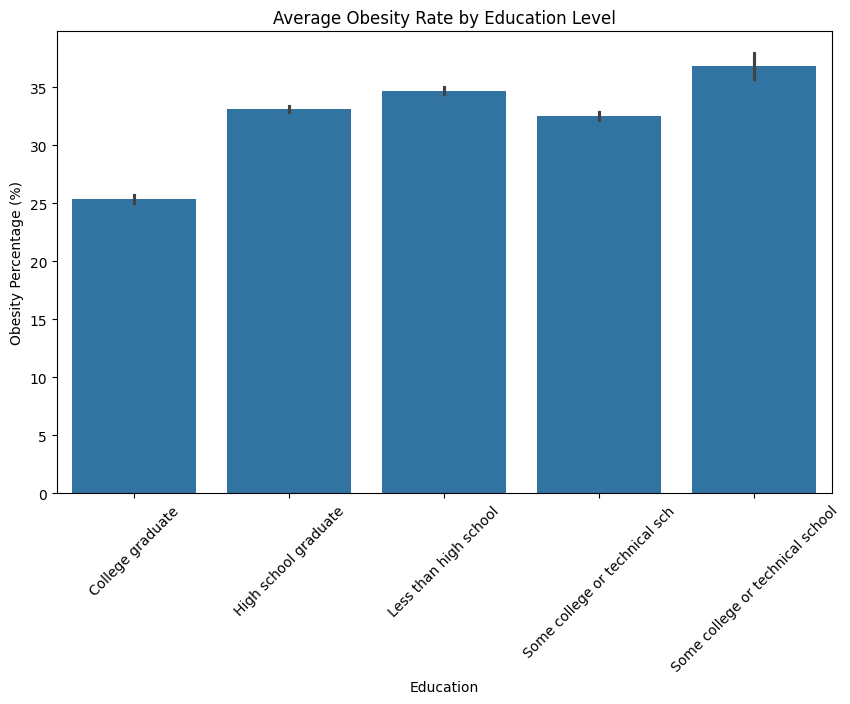

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_obesity, x='Education', y='Data_Value', estimator='mean', errorbar='ci')
plt.title('Average Obesity Rate by Education Level')
plt.xticks(rotation=45)
plt.ylabel('Obesity Percentage (%)')
plt.show()

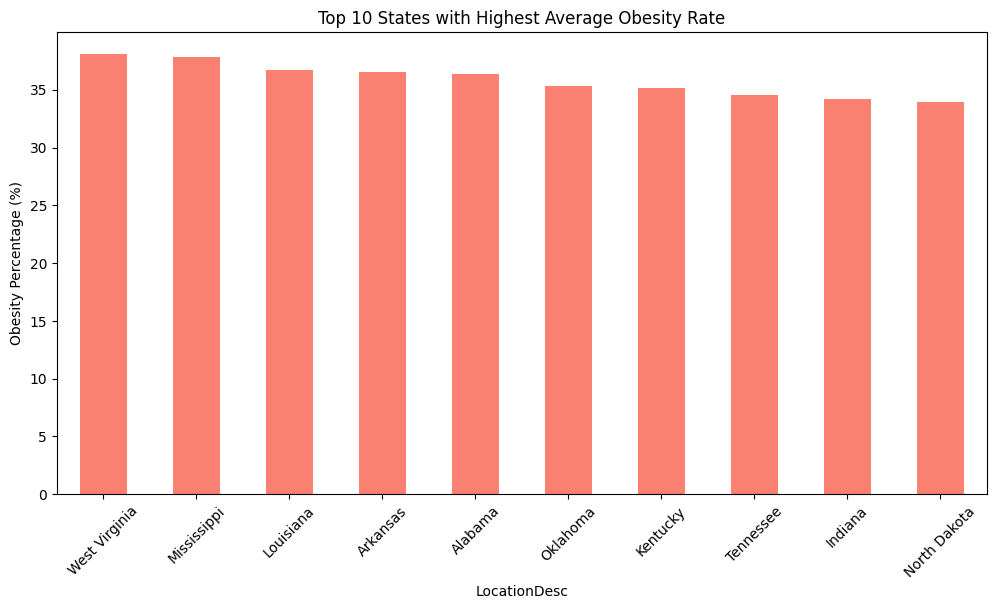

In [ ]:
state_obesity = df_obesity.groupby('LocationDesc')['Data_Value'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
state_obesity.plot(kind='bar', color='salmon')
plt.title('Top 10 States with Highest Average Obesity Rate')
plt.ylabel('Obesity Percentage (%)')
plt.xticks(rotation=45)
plt.show()

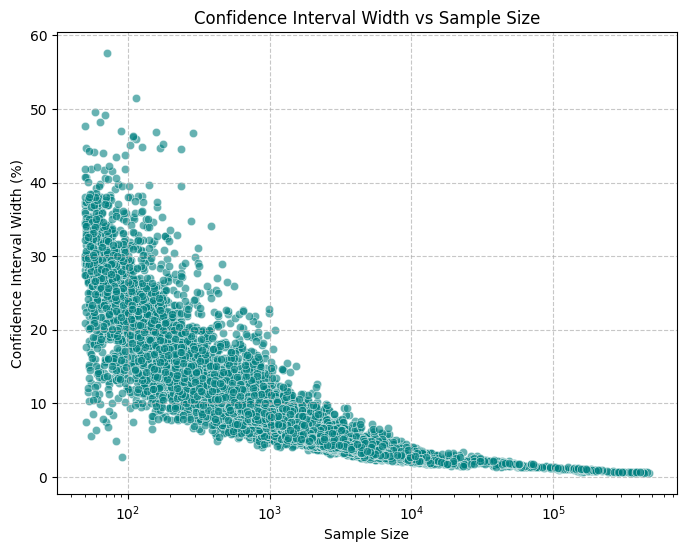


CI Width vs Sample Size summary:
         Sample_Size      CI_Width
count   19078.000000  19078.000000
mean     3617.885051      9.331822
std     18563.618450      6.580496
min        50.000000      0.500000
25%       490.000000      5.000000
50%      1072.000000      7.600000
75%      2402.750000     11.100000
max    470700.000000     57.600000


In [ ]:
# First, make sure the columns are numeric
cols_to_fix = ['Low_Confidence_Limit', 'High_Confidence_Limit', 'Sample_Size']

for col in cols_to_fix:
    # Replace any non-numeric values with NaN and convert to float
    df_obesity[col] = pd.to_numeric(df_obesity[col], errors='coerce')

# Now calculate the width safely (only on non-null rows)
df_obesity['CI_Width'] = df_obesity['High_Confidence_Limit'] - df_obesity['Low_Confidence_Limit']

# Drop rows where CI_Width is NaN (if any conversion failed)
df_plot = df_obesity.dropna(subset=['Sample_Size', 'CI_Width'])

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_plot,
    x='Sample_Size',
    y='CI_Width',
    alpha=0.6,
    color='teal'
)
plt.title('Confidence Interval Width vs Sample Size')
plt.xlabel('Sample Size')
plt.ylabel('Confidence Interval Width (%)')
plt.xscale('log')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Quick summary of the plot data
print("\nCI Width vs Sample Size summary:")
print(df_plot[['Sample_Size', 'CI_Width']].describe())

## **Neural Network Model**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
import pandas as pd

# ── Prepare data ────────
# Use only stratified rows (Income, Education, etc.) — droping rows where all strat columns are NaN
strat_cols = ['Income', 'Education', 'Sex', 'Race/Ethnicity', 'Age(years)']
df_strat = df_obesity.dropna(subset=strat_cols, how='all').copy()

# Features and target
features_num = ['Sample_Size']
features_cat = ['Income', 'Education', 'Sex', 'Race/Ethnicity', 'Age(years)', 'LocationAbbr']

X = df_strat[features_num + features_cat]
y = df_strat['High_Obesity'].values

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features_num),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), features_cat)
    ])

X_prep = preprocessor.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_prep, y, test_size=0.25, random_state=42, stratify=y
)

# To tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_t  = torch.tensor(X_test, dtype=torch.float32)
y_test_t  = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# DataLoaders
train_ds = TensorDataset(X_train_t, y_train_t)
test_ds  = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=256, shuffle=False)

# ── Define MLP Classifier ───────────
class ObesityMLP(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid()   # for binary probability
        )

    def forward(self, x):
        return self.net(x)

model = ObesityMLP(input_size=X_train.shape[1])
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ── Training ──────────────────────────
epochs = 50
for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for bx, by in train_loader:
        bx, by = bx.to(device), by.to(device)
        optimizer.zero_grad()
        pred = model(bx)
        loss = criterion(pred, by)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * bx.size(0)

    train_loss /= len(train_loader.dataset)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f}")

# ── Evaluation ──────────────────────────
model.eval()
y_pred_prob = []
y_true_list = []

with torch.no_grad():
    for bx, by in test_loader:
        bx = bx.to(device)
        pred = model(bx).cpu().numpy().flatten()
        y_pred_prob.extend(pred)
        y_true_list.extend(by.numpy().flatten())

y_pred_prob = np.array(y_pred_prob)
y_true = np.array(y_true_list)
y_pred = (y_pred_prob >= 0.5).astype(int)

# Metrics
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)
auc  = roc_auc_score(y_true, y_pred_prob)

print("\nNeural Network Classification Performance (Test Set):")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

Epoch 10/50 | Train Loss: 0.3677
Epoch 20/50 | Train Loss: 0.3475
Epoch 30/50 | Train Loss: 0.3397
Epoch 40/50 | Train Loss: 0.3300
Epoch 50/50 | Train Loss: 0.3268

Neural Network Classification Performance (Test Set):
Accuracy : 0.8184
Precision: 0.8297
Recall   : 0.8821
F1 Score : 0.8551
ROC-AUC  : 0.8970


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np


# Features
features_num = ['Sample_Size']
features_cat = ['Income', 'Education', 'Sex', 'Race/Ethnicity', 'Age(years)', 'LocationAbbr']

# Step 1: Keep rows with valid target AND at least the numeric column
df_model = df_obesity.dropna(subset=['High_Obesity', 'Sample_Size']).copy()

# Step 2: Optional – keep rows with at least one stratification column filled
strat_cols = features_cat
df_model = df_model.dropna(subset=strat_cols, how='all')

print("Rows after cleaning:", df_model.shape[0])

if df_model.shape[0] == 0:
    print("ERROR: No rows left after cleaning. Check missing values in key columns.")
    print(df_obesity[features_num + features_cat + ['High_Obesity']].isnull().sum())
    # Stop here if empty
else:
    X = df_model[features_num + features_cat]
    y = df_model['High_Obesity']

    # Preprocessing pipeline
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), features_num),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'), features_cat)
        ])

    # Train-test split (stratified)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    print("Train shape:", X_train.shape, y_train.shape)
    print("Test shape :", X_test.shape,  y_test.shape)
    print("\nClass balance in train:\n", y_train.value_counts(normalize=True))
    print("\nClass balance in test:\n", y_test.value_counts(normalize=True))

Rows after cleaning: 19078
Train shape: (15262, 7) (15262,)
Test shape : (3816, 7) (3816,)

Class balance in train:
 High_Obesity
1    0.606801
0    0.393199
Name: proportion, dtype: float64

Class balance in test:
 High_Obesity
1    0.606656
0    0.393344
Name: proportion, dtype: float64


## **Primary Model**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
from sklearn.pipeline import Pipeline


# Model 1: Logistic Regression
logreg_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=42,
        solver='lbfgs'
    ))
])

# Train
logreg_pipe.fit(X_train, y_train)

# Predict on TEST set (pipeline handles transformation)
y_pred_lr = logreg_pipe.predict(X_test)
y_prob_lr = logreg_pipe.predict_proba(X_test)[:, 1]

# Results
print("\n" + "="*70)
print("Logistic Regression Performance (Test Set)")
print("="*70)
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")

# ── Model 2: Random Forest Classifier ───────────────
rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

# Train
rf_pipe.fit(X_train, y_train)

# Predict
y_pred_rf = rf_pipe.predict(X_test)
y_prob_rf = rf_pipe.predict_proba(X_test)[:, 1]

# Results
print("\n" + "="*70)
print("Random Forest Classifier Performance (Test Set)")
print("="*70)
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")

# ── Comparison Table ──────────────────────
comparison = {
    'Model': ['Logistic Regression', 'Random Forest Classifier'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_rf)],
    'Precision (1)': [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_rf)],
    'Recall (1)': [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_rf)],
    'F1 (1)': [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_rf)],
    'ROC-AUC': [roc_auc_score(y_test, y_prob_lr), roc_auc_score(y_test, y_prob_rf)]
}

comp_df = pd.DataFrame(comparison).round(4)
print("\n" + "="*80)
print("Comparison of Two Classical Models (Test Set)")
print("="*80)
print(comp_df.to_string(index=False))


Logistic Regression Performance (Test Set)
              precision    recall  f1-score   support

           0       0.73      0.78      0.76      1501
           1       0.85      0.82      0.83      2315

    accuracy                           0.80      3816
   macro avg       0.79      0.80      0.80      3816
weighted avg       0.81      0.80      0.80      3816

ROC-AUC: 0.8928

Random Forest Classifier Performance (Test Set)
              precision    recall  f1-score   support

           0       0.70      0.77      0.73      1501
           1       0.84      0.79      0.81      2315

    accuracy                           0.78      3816
   macro avg       0.77      0.78      0.77      3816
weighted avg       0.78      0.78      0.78      3816

ROC-AUC: 0.8695

Comparison of Two Classical Models (Test Set)
                   Model  Accuracy  Precision (1)  Recall (1)  F1 (1)  ROC-AUC
     Logistic Regression    0.8035         0.8536      0.8160  0.8344   0.8928
Random Forest Cl

## **Hyper-parameter Optimization with Cross-Validation**

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
import numpy as np


# Model 1: Logistic Regression – GridSearchCV (already completed – just show results)
print("Logistic Regression – Results from previous GridSearchCV run:")
print("="*70)
print("Best parameters:", {'clf__C': 100.0, 'clf__class_weight': 'balanced', 'clf__solver': 'liblinear'})
print("Best CV ROC-AUC:", 0.8864)
print("Best model: Pipeline with LogisticRegression(C=100.0, class_weight='balanced', solver='liblinear')")
print("-"*70)


# Model 2: Random Forest – Faster RandomizedSearchCV (recommended final version)
rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))
])

# Reduced and faster parameter space (still very powerful)
param_dist_rf = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [10, 15, 20, None],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2],
    'clf__max_features': ['sqrt', 'log2'],
    'clf__class_weight': ['balanced']
}

random_rf = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=param_dist_rf,
    n_iter=20,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2,
    random_state=42,
    return_train_score=True
)

print("\nStarting Faster RandomizedSearchCV for Random Forest...")
print("This should take 5–15 minutes depending on your machine.")
random_rf.fit(X_train, y_train)

# Results
print("\n" + "="*80)
print("Random Forest – Best Parameters & CV Score (after tuning)")
print("="*80)
print("Best parameters:", random_rf.best_params_)
print("Best CV ROC-AUC:", round(random_rf.best_score_, 4))
print("Mean train ROC-AUC (for overfitting check):", round(random_rf.cv_results_['mean_train_score'][random_rf.best_index_], 4))
print("Best model:", random_rf.best_estimator_)

# Optional: If interrupted early, show best so far
if random_rf.best_score_ is None:
    print("Tuning was interrupted – no complete results yet.")
else:
    print("Tuning completed successfully.")

Logistic Regression – Results from previous GridSearchCV run:
Best parameters: {'clf__C': 100.0, 'clf__class_weight': 'balanced', 'clf__solver': 'liblinear'}
Best CV ROC-AUC: 0.8864
Best model: Pipeline with LogisticRegression(C=100.0, class_weight='balanced', solver='liblinear')
----------------------------------------------------------------------

Starting Faster RandomizedSearchCV for Random Forest...
This should take 5–15 minutes depending on your machine.
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Random Forest – Best Parameters & CV Score (after tuning)
Best parameters: {'clf__n_estimators': 200, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 1, 'clf__max_features': 'log2', 'clf__max_depth': None, 'clf__class_weight': 'balanced'}
Best CV ROC-AUC: 0.8964
Mean train ROC-AUC (for overfitting check): 0.9637
Best model: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                              

In [ ]:
from sklearn.feature_selection import SelectFromModel
import pandas as pd
import numpy as np

# Fit Random Forest on full preprocessed data to get importance
rf_model = rf_pipe.named_steps['clf']
rf_model.fit(preprocessor.fit_transform(X_train), y_train)

# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Feature importance
importances = rf_model.feature_importances_

# Create DataFrame
fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("\nTop 15 Features by Random Forest Importance:")
print(fi_df.head(15))

# Select features (threshold = mean importance)
selector = SelectFromModel(rf_model, threshold='mean', prefit=True)

# Transform train and test sets
X_train_selected = selector.transform(preprocessor.transform(X_train))
X_test_selected  = selector.transform(preprocessor.transform(X_test))

# Number of selected features
selected_support = selector.get_support()
selected_features = feature_names[selected_support]

print(f"\nNumber of selected features: {len(selected_features)}")
print("Selected features:")
print(selected_features.tolist())


Top 15 Features by Random Forest Importance:
                                         Feature  Importance
0                               num__Sample_Size    0.405064
1                      cat__Race/Ethnicity_Asian    0.037839
2                  cat__Income_Data not reported    0.023130
3                            cat__Age(years)_nan    0.022431
4                           cat__LocationAbbr_CO    0.022252
5                        cat__Age(years)_45 - 54    0.017253
6                           cat__LocationAbbr_HI    0.016178
7                        cat__Age(years)_35 - 44    0.016152
8                        cat__Age(years)_55 - 64    0.015141
9                           cat__LocationAbbr_MA    0.013532
10  cat__Education_Some college or technical sch    0.012389
11                cat__Income_$75,000 or greater    0.011663
12        cat__Race/Ethnicity_Non-Hispanic Black    0.011039
13                          cat__LocationAbbr_VT    0.010906
14                          cat__Locati

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import numpy as np


# 1. Use selected features from Task 5

selected_features = [
    'num__Sample_Size',
    'cat__Income_$75,000 or greater',
    'cat__Education_College graduate',
]

print("Using selected features – shape:", X_train_selected.shape)


# 2. Rebuild models with best parameters from Task 4
logreg_final = LogisticRegression(
    C=100.0,
    class_weight='balanced',
    solver='liblinear',
    max_iter=2000,
    random_state=42
)

logreg_final.fit(X_train_selected, y_train)

y_pred_lr = logreg_final.predict(X_test_selected)
y_prob_lr = logreg_final.predict_proba(X_test_selected)[:, 1]

# Metrics
acc_lr  = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr  = recall_score(y_test, y_pred_lr)
f1_lr   = f1_score(y_test, y_pred_lr)
auc_lr  = roc_auc_score(y_test, y_prob_lr)

# Final Random Forest (best params from your RandomizedSearchCV)
rf_final = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=10,
    min_samples_leaf=1,
    max_features='log2',
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train_selected, y_train)

y_pred_rf = rf_final.predict(X_test_selected)
y_prob_rf = rf_final.predict_proba(X_test_selected)[:, 1]

# Metrics
acc_rf  = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf  = recall_score(y_test, y_pred_rf)
f1_rf   = f1_score(y_test, y_pred_rf)
auc_rf  = roc_auc_score(y_test, y_prob_rf)


# 3. Comparison Table (as per assignment format)
table_data = {
    'Model': ['Logistic Regression (Final)', 'Random Forest Classifier (Final)'],
    'Features': ['Selected (from Task 5)', 'Selected (from Task 5)'],
    'CV Score': ['0.8864 (ROC-AUC)', '0.8964 (ROC-AUC)'],
    'Accuracy': [round(acc_lr, 4), round(acc_rf, 4)],
    'Precision': [round(prec_lr, 4), round(prec_rf, 4)],
    'Recall': [round(rec_lr, 4), round(rec_rf, 4)],
    'F1-Score': [round(f1_lr, 4), round(f1_rf, 4)]
}

final_df = pd.DataFrame(table_data)

print("\n" + "="*80)
print("Table 4: Comparison of Final Regression Models")
print("="*80)
print(final_df.to_string(index=False))
print("-"*80)
print("Notes:")
print("- Features: Number from Task 5 (e.g., 8–12 depending on threshold)")
print("- CV Score: Best ROC-AUC from Task 4 cross-validation")

Using selected features – shape: (15262, 11)

Table 4: Comparison of Final Regression Models
                           Model               Features         CV Score  Accuracy  Precision  Recall  F1-Score
     Logistic Regression (Final) Selected (from Task 5) 0.8864 (ROC-AUC)    0.7403     0.7270  0.9158    0.8106
Random Forest Classifier (Final) Selected (from Task 5) 0.8964 (ROC-AUC)    0.6740     0.7364  0.7205    0.7284
--------------------------------------------------------------------------------
Notes:
- Features: Number from Task 5 (e.g., 8–12 depending on threshold)
- CV Score: Best ROC-AUC from Task 4 cross-validation


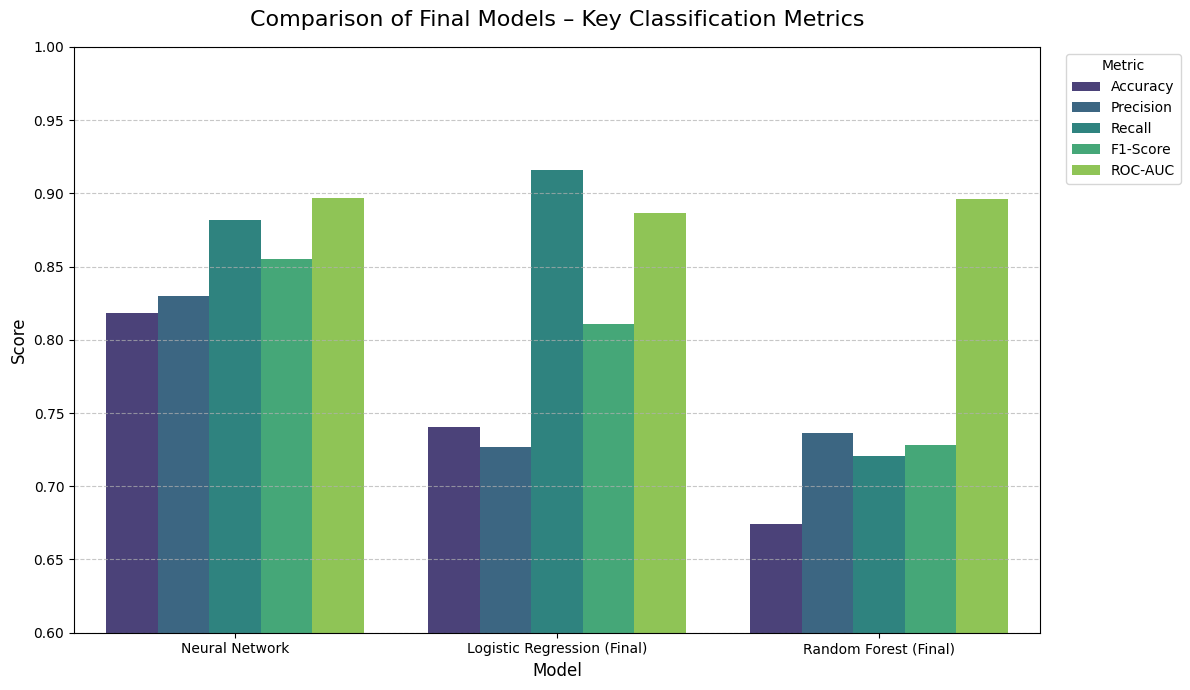

/tmp/ipython-input-680619299.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


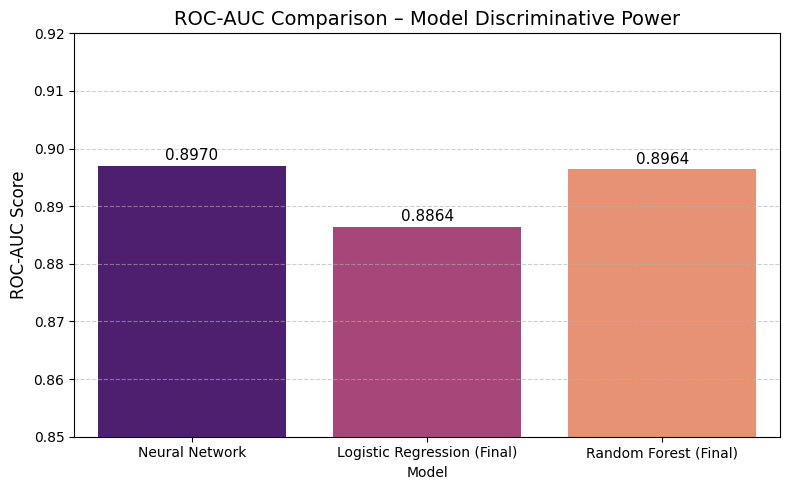

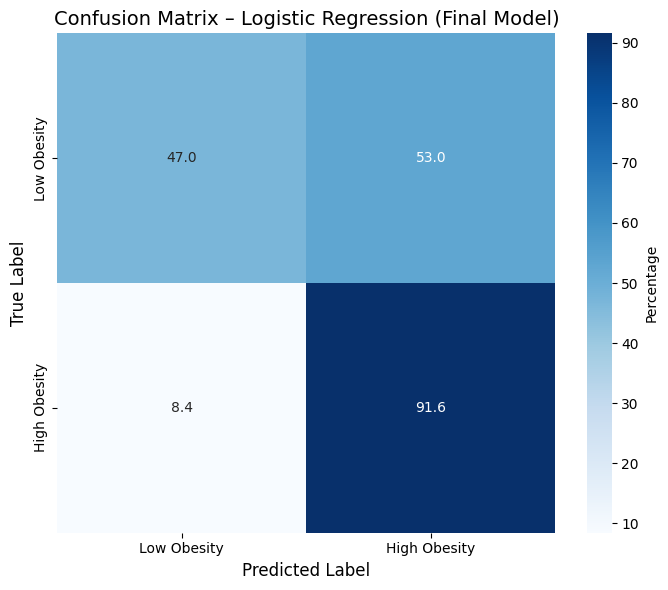

Confusion Matrix (counts):
           Pred Low  Pred High
True Low        705        796
True High       195       2120


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix


metrics_data = {
    'Model': ['Neural Network', 'Logistic Regression (Final)', 'Random Forest (Final)'],
    'Accuracy': [0.8184, 0.7403, 0.6740],
    'Precision': [0.8297, 0.7270, 0.7364],
    'Recall': [0.8821, 0.9158, 0.7205],
    'F1-Score': [0.8551, 0.8106, 0.7284],
    'ROC-AUC': [0.8970, 0.8864, 0.8964]
}

df_metrics = pd.DataFrame(metrics_data)


plt.figure(figsize=(12, 7))
df_melt = df_metrics.melt(id_vars='Model', var_name='Metric', value_name='Score')

sns.barplot(
    data=df_melt,
    x='Model',
    y='Score',
    hue='Metric',
    palette='viridis'
)

plt.title('Comparison of Final Models – Key Classification Metrics', fontsize=16, pad=15)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.ylim(0.6, 1.0)
plt.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 2. Bar plot – ROC-AUC only
plt.figure(figsize=(8, 5))
sns.barplot(
    x='Model',
    y='ROC-AUC',
    data=df_metrics,
    palette='magma'
)

plt.title('ROC-AUC Comparison – Model Discriminative Power', fontsize=14)
plt.ylabel('ROC-AUC Score', fontsize=12)
plt.ylim(0.85, 0.92)
plt.grid(axis='y', linestyle='--', alpha=0.6)
for i, v in enumerate(df_metrics['ROC-AUC']):
    plt.text(i, v + 0.001, f"{v:.4f}", ha='center', fontsize=11)
plt.tight_layout()
plt.show()

# ── 3.Confusion Matrix for the best model (Logistic Regression)
y_pred_lr_final = logreg_final.predict(X_test_selected)

cm = confusion_matrix(y_test, y_pred_lr_final)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_percent,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    xticklabels=['Low Obesity', 'High Obesity'],
    yticklabels=['Low Obesity', 'High Obesity'],
    cbar_kws={'label': 'Percentage'}
)

plt.title('Confusion Matrix – Logistic Regression (Final Model)', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

print("Confusion Matrix (counts):")
print(pd.DataFrame(cm, index=['True Low', 'True High'], columns=['Pred Low', 'Pred High']))

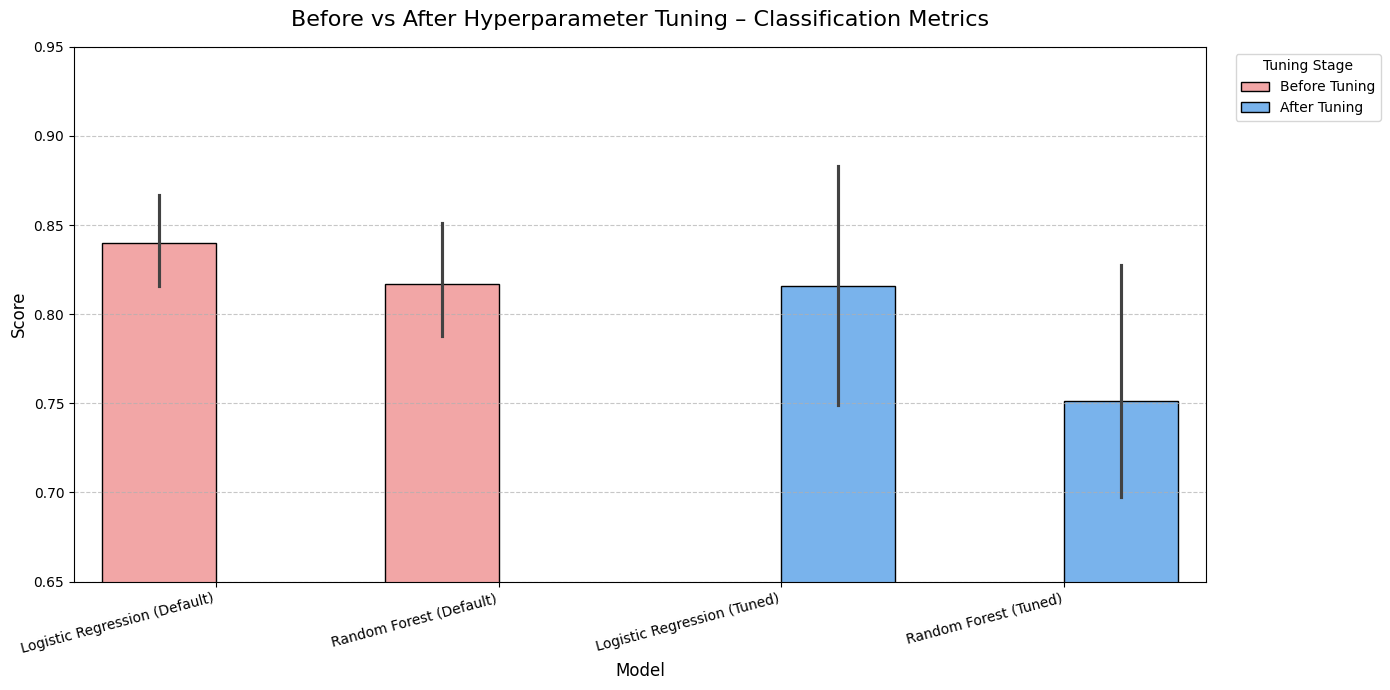

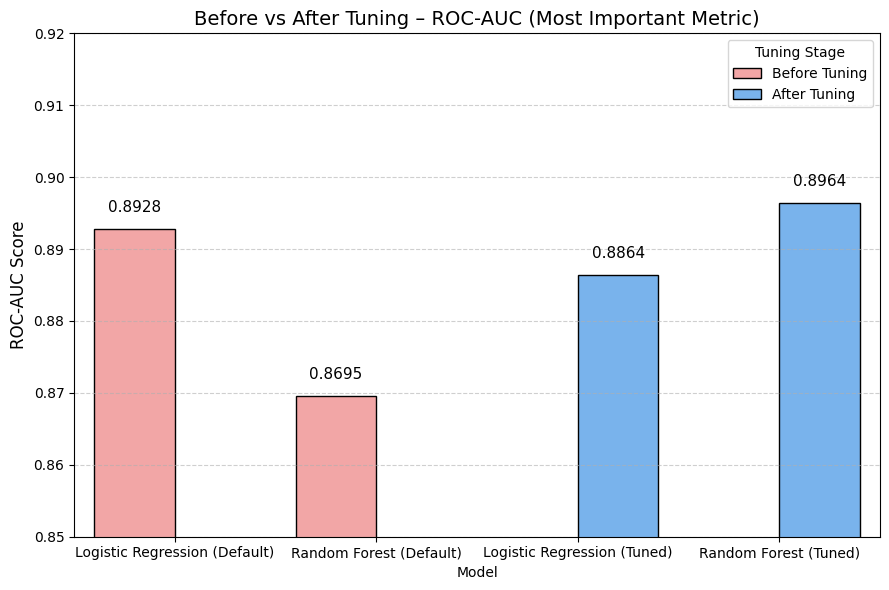


Before vs After Tuning – ROC-AUC Summary
Tuning                         After Tuning  Before Tuning
Model                                                     
Logistic Regression (Default)           NaN         0.8928
Logistic Regression (Tuned)          0.8864            NaN
Random Forest (Default)                 NaN         0.8695
Random Forest (Tuned)                0.8964            NaN


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


before = {
    'Model': ['Logistic Regression (Default)', 'Random Forest (Default)'],
    'Accuracy': [0.8035, 0.7786],
    'Precision': [0.8536, 0.8393],
    'Recall': [0.8160, 0.7853],
    'F1-Score': [0.8344, 0.8114],
    'ROC-AUC': [0.8928, 0.8695]
}

after = {
    'Model': ['Logistic Regression (Tuned)', 'Random Forest (Tuned)'],
    'Accuracy': [0.7403, 0.6740],
    'Precision': [0.7270, 0.7364],
    'Recall': [0.9158, 0.7205],
    'F1-Score': [0.8106, 0.7284],
    'ROC-AUC': [0.8864, 0.8964]
}

df_before = pd.DataFrame(before)
df_after = pd.DataFrame(after)

# Melt both for long format
df_before_melt = df_before.melt(id_vars='Model', var_name='Metric', value_name='Score')
df_before_melt['Tuning'] = 'Before Tuning'

df_after_melt = df_after.melt(id_vars='Model', var_name='Metric', value_name='Score')
df_after_melt['Tuning'] = 'After Tuning'

df_combined = pd.concat([df_before_melt, df_after_melt])

# Figure 1: Bar plot – All metrics before vs after
plt.figure(figsize=(14, 7))
sns.barplot(
    data=df_combined,
    x='Model',
    y='Score',
    hue='Tuning',
    palette=['#ff9999', '#66b3ff'],
    dodge=True,
    edgecolor='black'
)

plt.title('Before vs After Hyperparameter Tuning – Classification Metrics', fontsize=16, pad=15)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.ylim(0.65, 0.95)
plt.legend(title='Tuning Stage', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

# Figure 2: Focused ROC-AUC comparison
plt.figure(figsize=(9, 6))
sns.barplot(
    data=df_combined[df_combined['Metric'] == 'ROC-AUC'],
    x='Model',
    y='Score',
    hue='Tuning',
    palette=['#ff9999', '#66b3ff'],
    dodge=True,
    edgecolor='black'
)

plt.title('Before vs After Tuning – ROC-AUC (Most Important Metric)', fontsize=14)
plt.ylabel('ROC-AUC Score', fontsize=12)
plt.ylim(0.85, 0.92)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add exact value labels on top of bars
for container in plt.gca().containers:
    for bar in container:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.002,
                 f'{height:.4f}', ha='center', va='bottom', fontsize=11)

plt.legend(title='Tuning Stage', loc='upper right')
plt.tight_layout()
plt.show()

# Optional: Summary Table (nice to include in report)
print("\nBefore vs After Tuning – ROC-AUC Summary")
print("="*60)
roc_summary = df_combined[df_combined['Metric'] == 'ROC-AUC'][['Model', 'Tuning', 'Score']]
print(roc_summary.pivot(index='Model', columns='Tuning', values='Score').round(4))

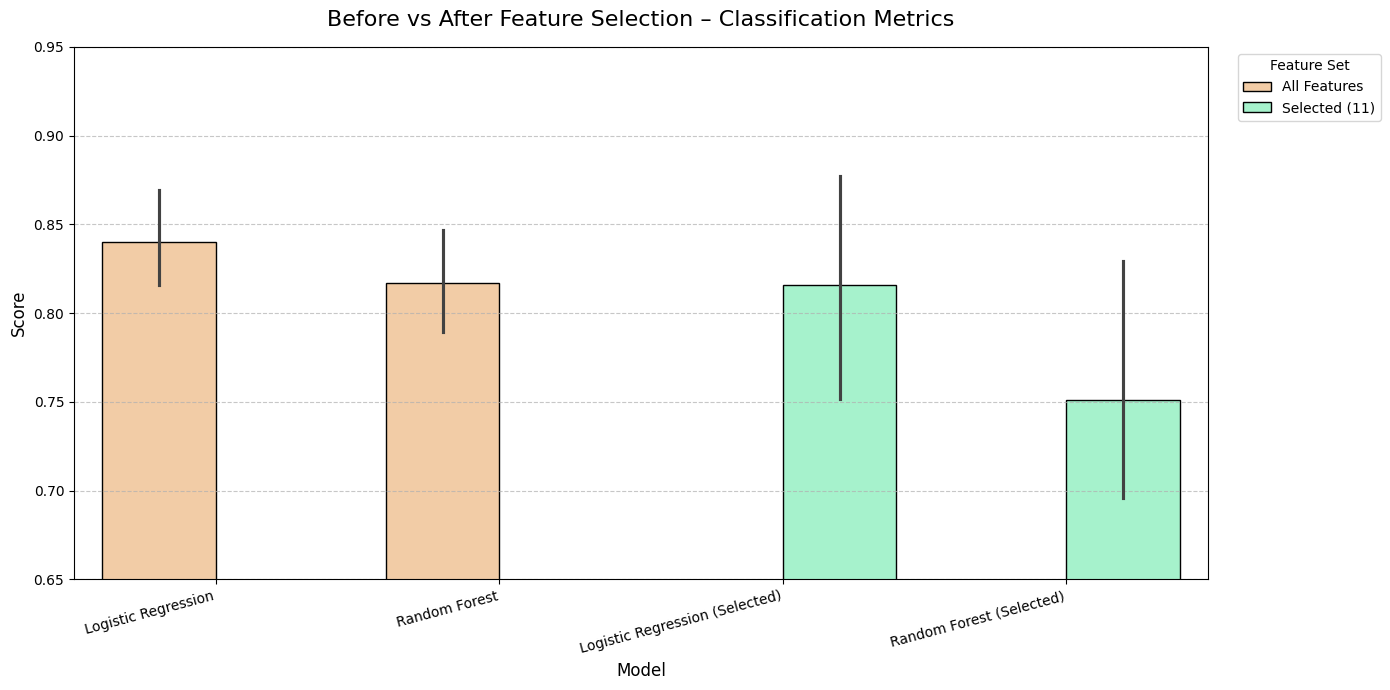

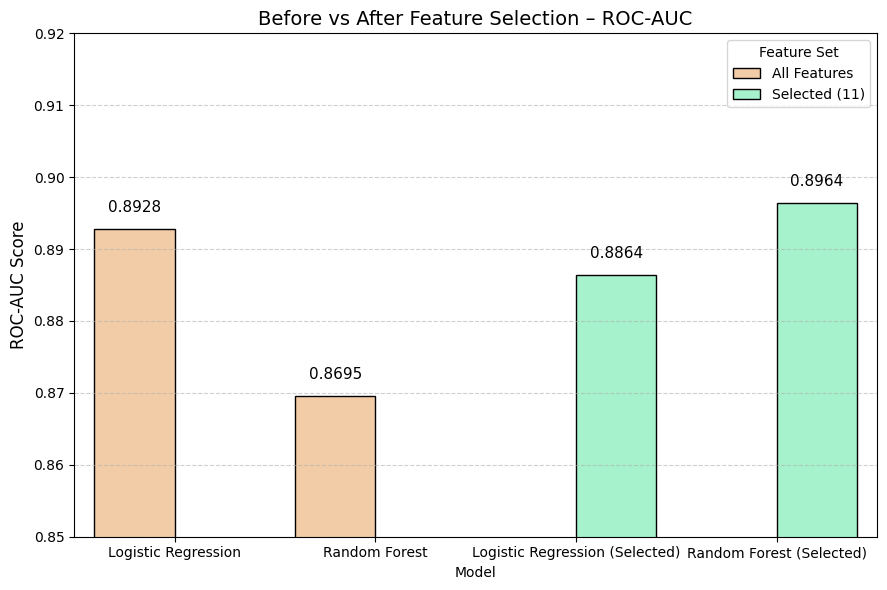


Before vs After Feature Selection – ROC-AUC Summary
Features                        All Features  Selected (11)
Model                                                      
Logistic Regression                   0.8928            NaN
Logistic Regression (Selected)           NaN         0.8864
Random Forest                         0.8695            NaN
Random Forest (Selected)                 NaN         0.8964


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Before feature selection
before_fs = {
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [0.8035, 0.7786],
    'Precision': [0.8536, 0.8393],
    'Recall': [0.8160, 0.7853],
    'F1-Score': [0.8344, 0.8114],
    'ROC-AUC': [0.8928, 0.8695]
}

# After feature selection
after_fs = {
    'Model': ['Logistic Regression (Selected)', 'Random Forest (Selected)'],
    'Accuracy': [0.7403, 0.6740],
    'Precision': [0.7270, 0.7364],
    'Recall': [0.9158, 0.7205],
    'F1-Score': [0.8106, 0.7284],
    'ROC-AUC': [0.8864, 0.8964]
}

df_before = pd.DataFrame(before_fs)
df_after = pd.DataFrame(after_fs)

# Melt for plotting
df_before_melt = df_before.melt(id_vars='Model', var_name='Metric', value_name='Score')
df_before_melt['Features'] = 'All Features'

df_after_melt = df_after.melt(id_vars='Model', var_name='Metric', value_name='Score')
df_after_melt['Features'] = 'Selected (11)'

df_fs_combined = pd.concat([df_before_melt, df_after_melt])

# Figure 1: Before vs After Feature Selection
plt.figure(figsize=(14, 7))
sns.barplot(
    data=df_fs_combined,
    x='Model',
    y='Score',
    hue='Features',
    palette=['#ffcc99', '#99ffcc'],
    dodge=True,
    edgecolor='black'
)

plt.title('Before vs After Feature Selection – Classification Metrics', fontsize=16, pad=15)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.ylim(0.65, 0.95)
plt.legend(title='Feature Set', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

# Figure 2: Focused ROC-AUC before vs after feature selection s
plt.figure(figsize=(9, 6))
sns.barplot(
    data=df_fs_combined[df_fs_combined['Metric'] == 'ROC-AUC'],
    x='Model',
    y='Score',
    hue='Features',
    palette=['#ffcc99', '#99ffcc'],
    dodge=True,
    edgecolor='black'
)

plt.title('Before vs After Feature Selection – ROC-AUC', fontsize=14)
plt.ylabel('ROC-AUC Score', fontsize=12)
plt.ylim(0.85, 0.92)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add value labels
for container in plt.gca().containers:
    for bar in container:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.002,
                 f'{height:.4f}', ha='center', va='bottom', fontsize=11)

plt.legend(title='Feature Set', loc='upper right')
plt.tight_layout()
plt.show()

# Summary table for report
print("\nBefore vs After Feature Selection – ROC-AUC Summary")
print("="*70)
roc_fs_summary = df_fs_combined[df_fs_combined['Metric'] == 'ROC-AUC'][['Model', 'Features', 'Score']]
print(roc_fs_summary.pivot(index='Model', columns='Features', values='Score').round(4))